# ELM corpus: elastic differential cross sections

Unlike KDUQ, CHUQ and Test, the ELM corpus is not defined by a table of EXFOR
subentries. It is a query -- every EXFOR data set for elastic nucleon scattering on a set of near-spherical targets between 10 and 200 MeV -- followed by a
sequence of human judgements: entries excluded as duplicates or as lacking
uncertainties, parses repaired by naming the right uncertainty columns, and individual
points corrected for apparent transcription errors.

Those judgements are the corpus. They are recorded in `nn_corpora.elm` with the reasons
given in the original ELM notebooks, and applied here.

Proton elastic data are stored as a ratio to Rutherford throughout, matching the other corpora in this repo. This is a departure from the original ELM notebooks, which keep absolute cross sections where EXFOR reports them that way; the conversion is exactly invertible given the tabulated energy and target.

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt

import numpy as np

from nn_corpora import elm, elm_curate, munge, plotting, serialize, spec

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## Targets

The corpus is restricted to near-spherical nuclei, where a spherical optical model is
defensible. The cut is on the quadrupole deformation, and drops $^{42}$Ca and $^{44}$Ca.

In [2]:
targets = spec.elm_targets()
print(f"{len(targets)} targets below beta2 = {spec.MAX_BETA2}:")
print(", ".join(f"{A if A else 'nat'}{__import__('periodictable').elements[Z].symbol}"
                for A, Z in sorted(targets, key=lambda t: (t[1], t[0]))))

21 targets below beta2 = 0.16:
40Ca, 48Ca, 64Ni, 86Sr, 88Sr, 90Zr, 92Zr, 94Zr, 96Zr, 92Mo, 94Mo, 116Sn, 118Sn, 120Sn, 122Sn, 124Sn, 138Ba, 144Sm, 148Sm, 206Pb, 208Pb


## Query

Both `dXS/dA` and `dXS/dRuth` are requested for protons. `exfor_tools` removes the
absolute measurement wherever the same subentry also reports a ratio at the same energy,
keeping the ratio -- the form the experimenters normalised.

In [3]:
nn = elm_curate.query_elastic(
    projectile=spec.PROJECTILES["neutron"], quantities=("dXS/dA",),
    targets=targets, einc_range=spec.ELM_ELASTIC_EINC_RANGE,
    min_num_pts=spec.ELM_MIN_NUM_PTS,
)
pp = elm_curate.query_elastic(
    projectile=spec.PROJECTILES["proton"], quantities=("dXS/dA", "dXS/dRuth"),
    targets=targets, einc_range=spec.ELM_ELASTIC_EINC_RANGE,
    min_num_pts=spec.ELM_MIN_NUM_PTS,
)
print(f"(n,n): {sum(len(m.data['dXS/dA'].entries) for m in nn.values())} entries parsed")
print(f"(p,p): {sum(len(m.data['dXS/dA'].entries) + len(m.data['dXS/dRuth'].entries) for m in pp.values())} entries parsed")

(n,n): 26 entries parsed
(p,p): 116 entries parsed


## Repair failed parses

An entry fails to parse when it reports several uncertainty columns and `exfor_tools`
cannot tell which is which. The recipes below come from reading each entry's EXFOR
`ERR-ANALYS` text, as recorded in the original notebooks.

In [4]:
result = elm_curate.ElmSectorResult(sector="elastic_diff_xs")
elm_curate.repair_failed_parses(nn, ("dXS/dA",), result)
elm_curate.repair_failed_parses(pp, ("dXS/dA", "dXS/dRuth"), result)
print("\n".join(sorted(set(result.repaired))) or "nothing to repair")

dXS/dA 10633 via ('DATA-ERR1',)
dXS/dA 10867 via ('ERR-T',)
dXS/dA 12701 via ('DATA-ERR1',)
dXS/dA 22987 via ('ERR-S',)
dXS/dA C0624 via ('DATA-ERR',)
dXS/dA D0289 via ('ERR-S', 'ERR-DIG')
dXS/dA F1173 via ('DATA-ERR2', 'ERR-DIG')
dXS/dA O0124 via ('DATA-ERR1',)
dXS/dA O0142 via ('ERR-T',)
dXS/dA O0208 via ('ERR-2',)
dXS/dA O0253 via ('ERR-1', 'ERR-DIG')
dXS/dA O0382 via ('ERR-T', 'DATA-ERR')
dXS/dA O0389 via ('ERR-2',)
dXS/dA T0101 via ('DATA-ERR',)
dXS/dRuth O0211 via ('DATA-ERR', 'ERR-T')
dXS/dRuth O0253 via ('ERR-1', 'ERR-DIG')
dXS/dRuth O0287 via ('DATA-ERR',)
dXS/dRuth O0302 via ('DATA-ERR1', 'ERR-DIG')
dXS/dRuth O0328 via ('ERR-1', 'ERR-DIG')
dXS/dRuth O0389 via ('ERR-2',)
dXS/dRuth O0552 via ('DATA-ERR', 'ERR-T')


## Exclusions

Entries rejected as duplicates, as lacking uncertainties, or as inconsistent with other
measurements of the same quantity. Every reason is the one recorded in the original
notebooks.

In [5]:
elm_curate.exclude_entries(nn, "dXS/dA", elm.EXCLUDED_NN, result)
elm_curate.exclude_entries(pp, "dXS/dA", elm.EXCLUDED_PP_ABSOLUTE, result)
elm_curate.exclude_entries(pp, "dXS/dRuth", elm.EXCLUDED_PP_RUTHERFORD, result)
print("\n".join(sorted(set(result.excluded))))

dXS/dA 14317: duplicate
dXS/dA C0078: redundant, huge uncertainties
dXS/dA C0081: apparent mistranscriptions
dXS/dA C3000: no uncertainties
dXS/dA E0249: duplicate to E0166 and O0032
dXS/dA E0795: duplicate, no uncertainties
dXS/dA E0904: no uncertainties
dXS/dA O0032: duplicate to E0166 and E0249
dXS/dA O0166: ratio to Rutherford does not go to 1 at low angle
dXS/dA O0253: duplicate to the ratio to Rutherford from the same entry
dXS/dA O0553: ratio to Rutherford does not go to 1 at low angle
dXS/dA T0289: no uncertainties
dXS/dRuth C1019: old and in poor agreement with other measurements due to normalization, but no normalization uncertainty given
dXS/dRuth C3001: no uncertainties
dXS/dRuth E0120: no uncertainties
dXS/dRuth F0733: no uncertainties
dXS/dRuth O0169: no uncertainties
dXS/dRuth O0300: no uncertainties
dXS/dRuth O0432: no uncertainties
dXS/dRuth O0490: no uncertainties
dXS/dRuth O0581: no uncertainties
dXS/dRuth O1199: angles in EXFOR are systematically offset compared to 

## Point-level corrections

Found by plotting the data and looking: a mistranscribed point sits an order of
magnitude away from its neighbours. Each correction records what was changed.

In [6]:
elm_curate.apply_point_fixes({**nn, **pp}, result)
elm_curate.apply_uncertainty_patches({**nn, **pp}, result)
elm_curate.apply_uncertainty_transplant(pp, result)
print("\n".join(sorted(set(result.repaired))))

C2174 8th point increased by a factor of 10
O0142 12th to last point decreased by a factor of 10
O0157 1st point decreased by a factor of 10
O0211 12th from last point decreased by a factor of 10
dXS/dA 10633 via ('DATA-ERR1',)
dXS/dA 10867 via ('ERR-T',)
dXS/dA 12701 via ('DATA-ERR1',)
dXS/dA 22987 via ('ERR-S',)
dXS/dA C0624 via ('DATA-ERR',)
dXS/dA D0289 via ('ERR-S', 'ERR-DIG')
dXS/dA F1173 via ('DATA-ERR2', 'ERR-DIG')
dXS/dA O0124 via ('DATA-ERR1',)
dXS/dA O0142 via ('ERR-T',)
dXS/dA O0208 via ('ERR-2',)
dXS/dA O0253 via ('ERR-1', 'ERR-DIG')
dXS/dA O0382 via ('ERR-T', 'DATA-ERR')
dXS/dA O0389 via ('ERR-2',)
dXS/dA T0101 via ('DATA-ERR',)
dXS/dRuth O0211 via ('DATA-ERR', 'ERR-T')
dXS/dRuth O0253 via ('ERR-1', 'ERR-DIG')
dXS/dRuth O0287 via ('DATA-ERR',)
dXS/dRuth O0302 via ('DATA-ERR1', 'ERR-DIG')
dXS/dRuth O0328 via ('ERR-1', 'ERR-DIG')
dXS/dRuth O0389 via ('ERR-2',)
dXS/dRuth O0552 via ('DATA-ERR', 'ERR-T')


## Munge and serialize

In [7]:
elm_curate.finalize(nn, "elastic_diff_xs", "neutron", result)
elm_curate.finalize(pp, "elastic_diff_xs", "proton", result)
print(result.summary())

elm/elastic_diff_xs
  targets                0
  measurements           233
  data points            8061
  excluded
    dXS/dA 14317: duplicate
    dXS/dA O0032: duplicate to E0166 and E0249
    dXS/dA E0249: duplicate to E0166 and O0032
    dXS/dA C0078: redundant, huge uncertainties
    dXS/dA E0795: duplicate, no uncertainties
    dXS/dA O0032: duplicate to E0166 and E0249
    dXS/dA E0249: duplicate to E0166 and O0032
    dXS/dA O0253: duplicate to the ratio to Rutherford from the same entry
    dXS/dA O0553: ratio to Rutherford does not go to 1 at low angle
    dXS/dA O0032: duplicate to E0166 and E0249
    dXS/dA E0249: duplicate to E0166 and O0032
    dXS/dA O0032: duplicate to E0166 and E0249
    dXS/dA T0289: no uncertainties
    dXS/dA T0289: no uncertainties
    dXS/dA O0032: duplicate to E0166 and E0249
    dXS/dA C3000: no uncertainties
    dXS/dA E0904: no uncertainties
    dXS/dA E0904: no uncertainties
    dXS/dA O0032: duplicate to E0166 and E0249
    dXS/dA O0166: ra

## Inspect

Plotted by target and grouped by incident energy, offset for legibility. This is the
view the corrections above were made from.

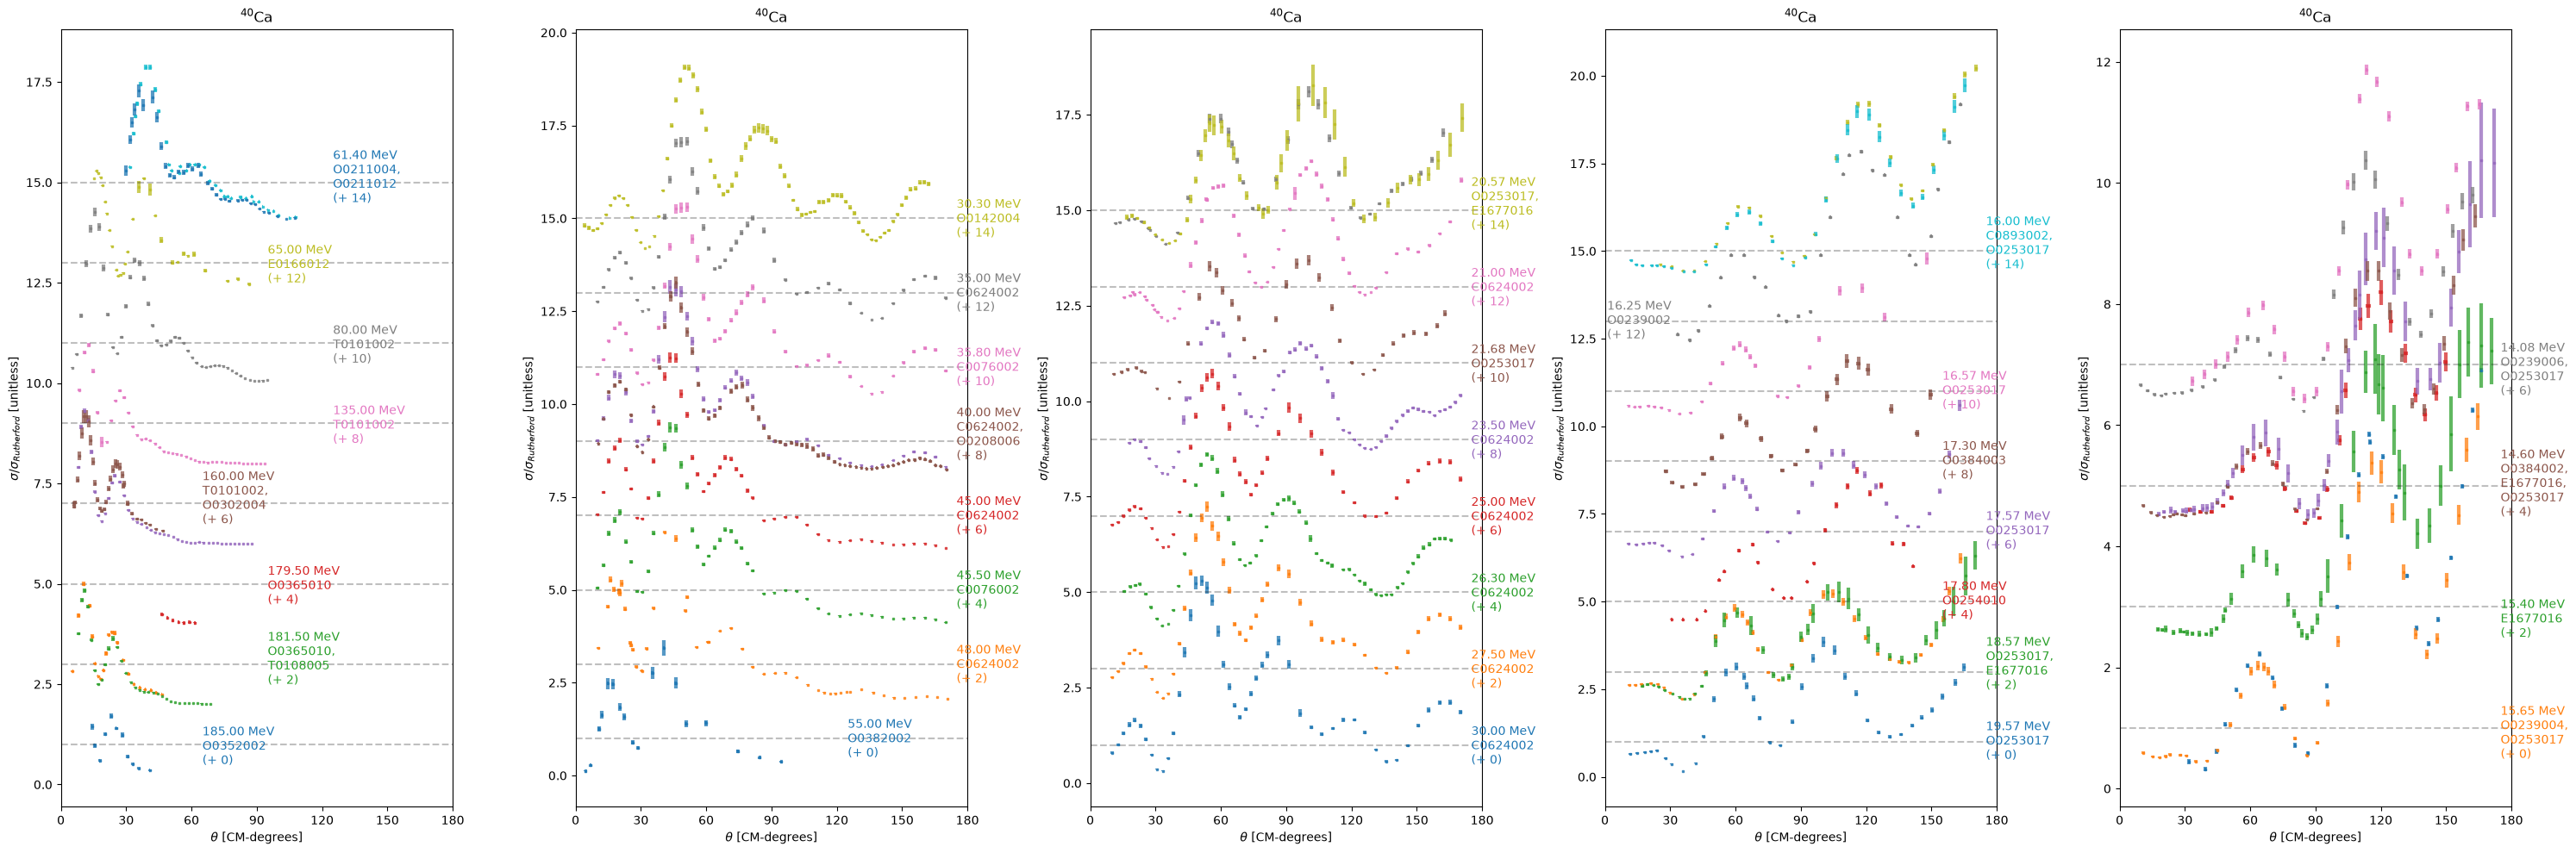

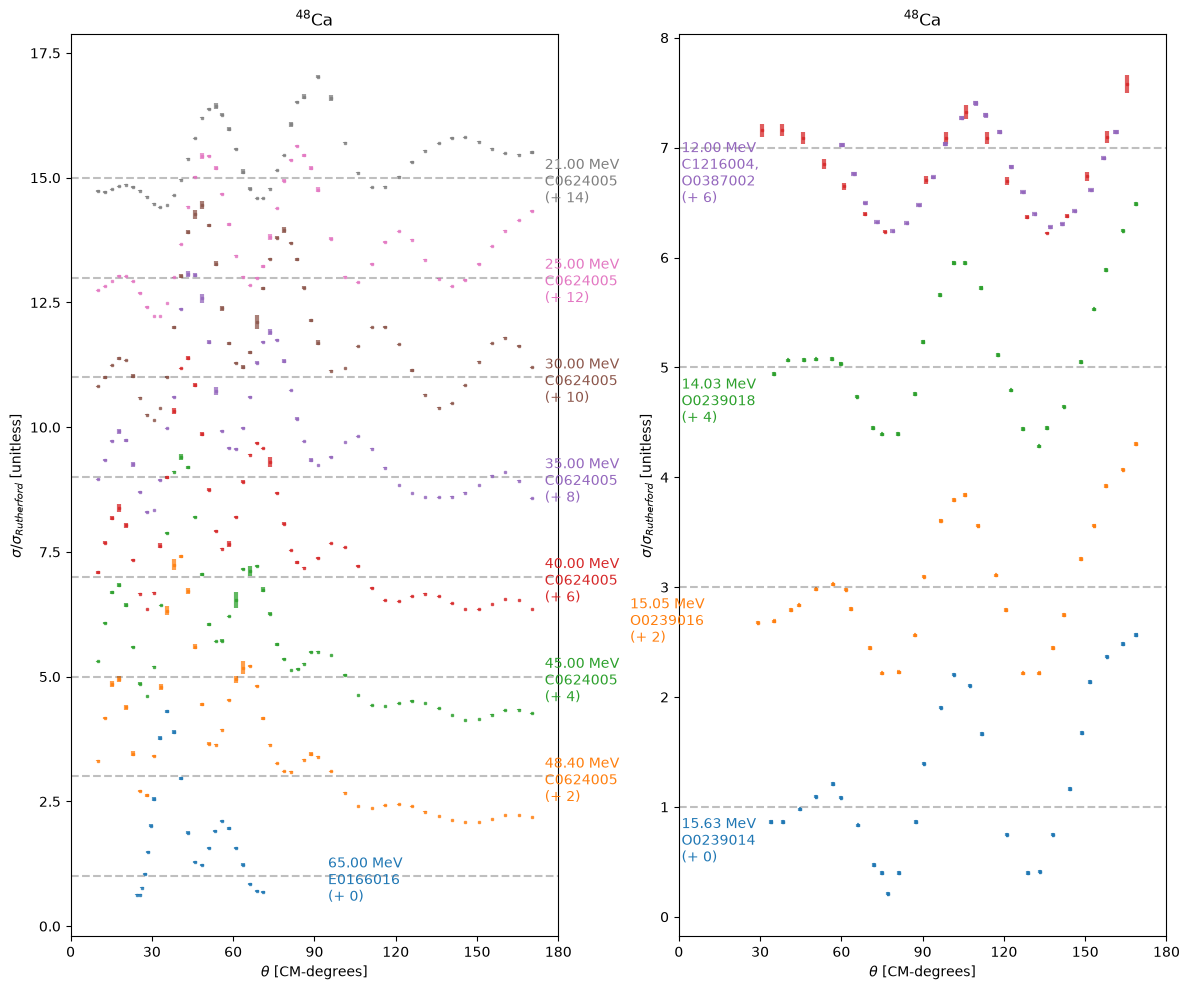

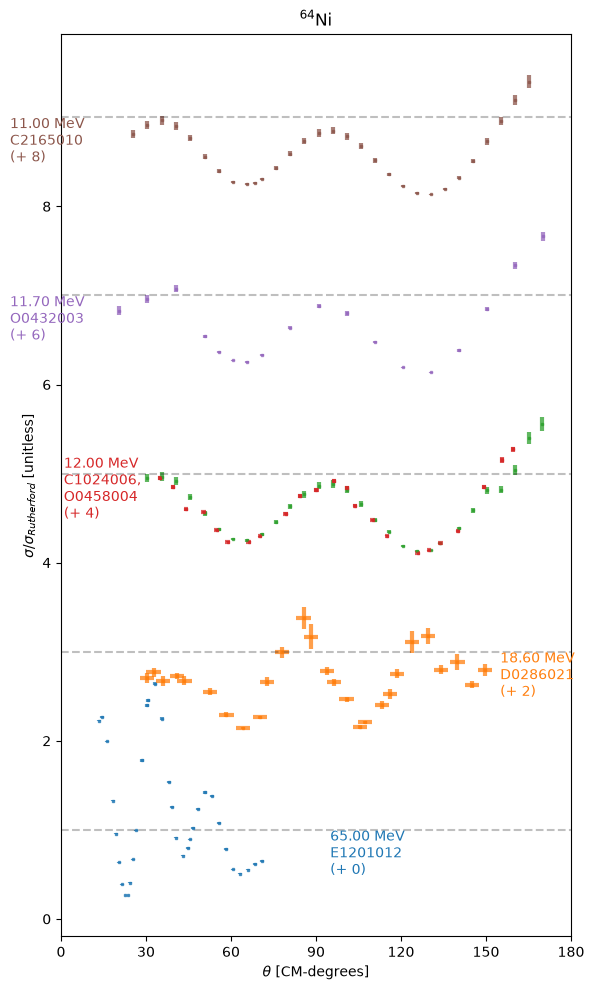

In [8]:
for target, multi in sorted(pp.items())[:4]:
    measurements = [m for q in multi.data.values()
                    for e in q.entries.values() for m in e.measurements]
    if measurements:
        plotting.plot_angular(measurements, title=plotting._latex(
            f"{target[0] or 'nat'}{__import__('periodictable').elements[target[1]].symbol}"))
plt.show()

## Write

In [9]:
serialize.write_sector(result.records, corpus="elm", sector="elastic_diff_xs",
                       bibtex=result.bibtex)
print(f"wrote {len(result.records)} measurements to data/elm/elastic_diff_xs/")


wrote 233 measurements to data/elm/elastic_diff_xs/
